# Prototype Fisher forecast

We prototype a Fisher forecast using `jax.jacfwd` and a Gaussian covariance for $P^\ell_{\mathrm{1-loop}}(k)$ where $\ell=[0,2,4]$ for a single redshift bin.

To connect a cosmological model to the observed power spectrum multipoles, we use [cosmopower-jax](https://github.com/dpiras/cosmopower-jax) to emulate the linear matter power spectrum$^*$ and [ps_1loop_jax](https://github.com/archaeo-pteryx/ps_1loop_jax) to obtain the power spectrum multipoles.

$^*$List of cosmological model emulators compatible with `cosmopower-jax` is available on [cosmopower-organization repo](https://github.com/cosmopower-organization).

## Modules

In [1]:
import os

### matplotlib

import matplotlib
%matplotlib inline
%config InlineBackend.figure_format = 'retina'
import matplotlib.pyplot as plt
plt.rcParams.update({
    "text.usetex": True,
    "font.family": "sans-serif",
    "font.sans-serif": "Computer Modern",
    "font.size": 22})

from matplotlib.ticker import MultipleLocator, FormatStrFormatter

### numpy

import numdifftools as nd
import numpy as np

### jax

import jax
jax.config.update("jax_enable_x64", True) # Optional: double precision
import jax.numpy as jnp
import jax.scipy as jsp

### background cosmology

from ps_1loop_jax import background as bg

### jaxptpolypol

from jaxptpolypol.model import CosmoEmulator, PS1LoopModel
from jaxptpolypol.params import (
    CosmoParams,
    FullShapeSurveyParams,
    pack_pk_params,
    unpack_pk_params,
)
from jaxptpolypol.covariance import gaussian_covariance
from jaxptpolypol.inference import fisher_matrix, sigma_from_fisher, marginalize_fisher
from jaxptpolypol.plotting import plot_contours, plot_Gaussian, triangle_plot
from jaxptpolypol.theory import make_pk_ell_fn
from jaxptpolypol.marginalization import make_lcdm_corner_specs, project_case_to_specs


## Emulator Classes

## Models and emulators

For each cosmological model, we need to specify the path in `CosmoEmulator(emulator_path=)`. The cosmological models and the corresponding paths are as follows:

- model A: The standard cosmological model flat $\Lambda$CDM: `cosmopower-jax-for-pfs/cosmology/jense2024/jense_2023_camb_lcdm/networks/jense_2023_camb_lcdm_Pk_lin.npz`.
- model B: flat $\Lambda$CDM with massive neutrinos $m_\nu$CDM: `cosmopower-jax-for-pfs/cosmology/jense2024/jense_2023_camb_mnu/networks/jense_2023_camb_mnu_Pk_lin.npz`.

In [2]:
### cosmopower_jax - model and emulator initalization

#### model A
model_path='/Users/nguyenmn/cosmopower-jax-for-pfs/cosmology/jense2024/jense_2023_camb_lcdm/networks/jense_2023_camb_lcdm_Pk_lin.npz'

#### model B
#model_path='/Users/nguyenmn/cosmopower-jax-for-pfs/cosmology/jense2024/jense_2023_camb_mnu/networks/jense_2023_camb_mnu_Pk_lin.npz'

pklin_emulator = CosmoEmulator(probe='custom_log', emulator_path=model_path)
print("Emulator input parameters:",pklin_emulator.parameters)

Tried to load pickle file from pre-trained model, but failed.
This usually means that you have TF>=2.14, or that you are loading a model that was trained on PCA but loaded with the log (or viceversa), or that you are loading a non-standard model from the cosmopower-organization repo.
Falling back to the dictionary, in case this also fails or does not output the right shape make sure you ran the `convert_tf214.py` script, and that a `.npz` file exists among the trained models, and that you ran `pip install .`. Also make sure that you are asking for the right probe between `custom_log` and `custom_pca`.
Emulator input parameters: ['ombh2' 'omch2' 'logA' 'ns' 'h' 'z' 'A_b' 'eta_b' 'logT_AGN']


In [3]:
### ps_1loop_jax - model and emulator initalization
ps1loop_model=PS1LoopModel(do_irres=True)
#print("1-loop Pk terms:", ps1loop_model.pk_terms)

## Compute Jacobian

First we define input parameters. The input parameters can be classified into two types:

- (1) cosmological parameters,
- (2) survey parameters.

(1) The cosmological parameters are universal for the whole survey. So we can define them once for all redshift bins.

In [4]:
### Cosmology parameters
#### model A
cosmo_dict = {
    'ombh2': 0.02242,
    'omch2': 0.11933,
    'logA':  3.047,
    'ns':    0.9665,
    'h':     0.6766,
    'z':     1.1,
    'A_b':   3.13,
    'eta_b': 0.603,
    'logT_AGN': 7.8
}
cosmo = CosmoParams(cosmo_dict)

#### model B
#### Specify cosmological parameters for model B, note that model B includes an additional parameter `mnu` for neutrino mass.
#### `mnu=0.06`
#### You can check the list of model parameters by calling `pklin_emulator.parameters` as above.

(2) While some survey parameters are also universal, many vary between redshift bins, i.e. $\phi=\phi(z)$. The galaxies observed by the PFS survey will be classified into 6 redshift bins as follows:

- Bin $z_1$: 0.6< $z$ <0.8
- Bin $z_2$: 0.8 < $z$ < 1.0
- Bin $z_3$: 1.0 < $z$ < 1.2
- Bin $z_4$: 1.2 < $z$ < 1.4
- Bin $z_5$: 1.4 < $z$ < 1.6
- Bin $z_6$: 1.6 < $z$ < 2.0
- Bin $z_7$: 2.0 < $z$ < 2.4

Usually, for each redshift bin $i$, we need to identify an effective mean redshift $z_i$ at which we will evaluate the power spectrum multipoles $P^\ell(k,z_i)$. $z_i$ is a weighted mean value of the redshifts of galaxies in each bin. For this forecast, we can simply assume $z_i$ to be equal to the (unweighted) mean of $z$, hence

- $z_1$ = 0.7
- $z_2$ = 0.9
- $z_3$ = 1.1
- $z_4$ = 1.3
- $z_5$ = 1.5
- $z_6$ = 1.8
- $z_7$ = 2.2

(2a) Universal survey parameters.

In [5]:
### The multipoles measured in each redshift bin
ells=[0,2,4] # monopole, quadrupole, hexadecapole
a0=0. # we fix these bias stochasticity coefficients to 0 in this forecast
a2=0. # we fix these bias stochasticity coefficients to 0 in this forecast

(2b) Survey parameters vary with redshift.

In [6]:
### Survey volume within the redshift bin
#### Bin 1
#V=0.59*(1000.**3) # in unit of [Mpc/h]^3
#### Bin 2
#V=0.79*(1000.**3) # in unit of [Mpc/h]^3
#### Bin 3
#V=0.96*(1000.**3) # in unit of [Mpc/h]^3
#### Bin 4
V=1.09*(1000.**3) # in unit of [Mpc/h]^3
#### Bin 5
#V=1.19*(1000.**3) # in unit of [Mpc/h]^3
#### Bin 6
#V=2.58*(1000.**3) # in unit of [Mpc/h]^3
#### Bin 7
#V=2.71*(1000.**3) # in unit of [Mpc/h]^3

In [7]:
### Nonlinear scales in each redshift bin
#### Bin 1
#knl=0.52 # in unit of [h/Mpc]
#### Bin 2
#knl=0.65 # in unit of [h/Mpc]
#### Bin 3
#knl=0.82 # in unit of [h/Mpc]
#### Bin 4
knl=1.02 # in unit of [h/Mpc]
#### Bin 5
#knl=1.29 # in unit of [h/Mpc]
#### Bin 6
#knl=1.82 # in unit of [h/Mpc]
#### Bin 7
#knl=2.88 # in unit of [h/Mpc]

In [8]:
### Galaxy number density within the redshift bin
#### Bin 1
#ndens= 3.06e-04 # in unit of [h/Mpc]^3 (since ndens=N_gal/V)
#### Bin 2
#ndens=9.61e-04 # in unit of [h/Mpc]^3 (since ndens=N_gal/V)
#### Bin 3
#ndens=9.75e-4 # in unit of [h/Mpc]^3 (since ndens=N_gal/V)
#### Bin 4
ndens=6.54e-4 # in unit of [h/Mpc]^3 (since ndens=N_gal/V)
#### Bin 5
#ndens=3.40e-4 # in unit of [h/Mpc]^3 (since ndens=N_gal/V)
#### Bin 6
#ndens=2.02e-4 # in unit of [h/Mpc]^3 (since ndens=N_gal/V)
#### Bin 7
#ndens=3.51e-4 # in unit of [h/Mpc]^3 (since ndens=N_gal/V)

The redshift evolution of some survey parameters (mostly galaxy bias parameters) can be approximated by fitting functions. Below, we define those functions to derive the correct parameters for each redshift bin.

    For reference, see Eq.~(3.6)-(3.14) of [1907.06666](https://arxiv.org/abs/1907.06666).

In [9]:
def b1z(z):
    return 0.9+0.4*z # Eq.~(3.6)

def b2z(z):
    return -0.704 - 0.208*z + 0.183*z**2 - 0.00771*z**3 # Eq.~(3.7)

def bG2z(z):
    return -(2./7.)*(b1z(z)-1.) # Eq.~(3.8)

def bGamma3z(z):
    return (23./42.)*(b1z(z)-1.) # Eq.~(3.8)

Some bias functions involve the linear growth factor $D_+(z)$ so we must evaluate $D_+(z)$. Below we use the Heath integral implemented in `ps_1loop_jax.background.growth_factor` to compute $D_+(z)$, normalized to unity at $z=0$.

In [10]:
# Linear growth factor D+(z) via ps_1loop_jax.background (Heath integral)
def Dplusz(z):
    return float(bg.growth_factor(
        cosmo_dict['ombh2'], cosmo_dict['omch2'], cosmo_dict['h'], z, mnu=0.06
    ))

In [11]:
def c0z(z):
    return 25.*Dplusz(z)**2 # Eq.~(3.12)
    
def c2z(z):
    return 25.*Dplusz(z)**2 # same as c0, Eq.~(3.12)

def c4z(z):
    return Dplusz(z)**2 # Eq.~(3.13)

In [12]:
### fiducial bias parameters

survey = FullShapeSurveyParams(
    shared={
        'bias': {
            'b1': b1z(cosmo_dict['z']),
            'b2': b2z(cosmo_dict['z']),
            'bG2': bG2z(cosmo_dict['z']),
            'bGamma3': bGamma3z(cosmo_dict['z']),
        },
        'stoch': {
            'P_shot': 1.0,
        },
        'k_nl': knl,
        'ndens': ndens,
    },
    pk={
        'ctr': {
            'c0': c0z(cosmo_dict['z']),
            'c2': c2z(cosmo_dict['z']),
            'c4': c4z(cosmo_dict['z']),
            'cfog': knl**(-4),
        },
        'stoch': {
            'a0': a0,
            'a2': a2,
        },
    },
)
pk_survey_keys = survey.pk_param_keys

# Pack Fisher parameters into a flat array, excluding the `k_nl` and `ndens` parameters
fid_params = cosmo.param_dict | survey.to_model_dict('pk')
print(fid_params)


{'ombh2': 0.02242, 'omch2': 0.11933, 'logA': 3.047, 'ns': 0.9665, 'h': 0.6766, 'z': 1.1, 'A_b': 3.13, 'eta_b': 0.603, 'logT_AGN': 7.8, 'bias': {'b1': Array(1.34, dtype=float64), 'b2': Array(-0.72163201, dtype=float64), 'bG2': Array(-0.09714286, dtype=float64), 'bGamma3': Array(0.18619048, dtype=float64)}, 'stoch': {'P_shot': Array(1., dtype=float64), 'a0': Array(0., dtype=float64), 'a2': Array(0., dtype=float64)}, 'k_nl': Array(1.02, dtype=float64), 'ndens': Array(0.000654, dtype=float64), 'ctr': {'c0': Array(8.48094646, dtype=float64), 'c2': Array(8.48094646, dtype=float64), 'c4': Array(0.33923786, dtype=float64), 'cfog': Array(0.92384543, dtype=float64)}}


### Helpers

### Wrappers

Some wrappers to pack and wrap the methods `cosmopower-jax.CosmoPowerJax.predict()` and `ps_1loop_jax.PowerSpectrum1Loop.get_pk_ell()` for `jax.jacfwd()` and `numdifftools.Jacobian()` calls.

In [13]:
# No wrapper needed — make_pk_ell_fn handles everything

### Sanity check and visual inspection

Just a check to make sure our helpers and wrappers work as intended.

In [14]:
packed_params = pack_pk_params(cosmo, [survey])
print("Packed parameter vector:")
print(type(packed_params))
print(packed_params)
unpacked_cosmo, unpacked_surveys = unpack_pk_params(
    packed_params,
    cosmo.param_keys,
    cosmo.param_sizes,
    pk_survey_keys,
    n_bins=1,
)
unpacked_survey = unpacked_surveys[0]
print("Whether the unpacked and the original cosmological parameter dictionaries are the same:")
print(unpacked_cosmo == cosmo)
print("Whether the unpacked and the original bias+survey parameter dictionaries are the same:")
print(unpacked_survey == survey)


Packed parameter vector:
<class 'jaxlib._jax.ArrayImpl'>
[ 2.24200000e-02  1.19330000e-01  3.04700000e+00  9.66500000e-01
  6.76600000e-01  1.10000000e+00  3.13000000e+00  6.03000000e-01
  7.80000000e+00  1.34000000e+00 -7.21632010e-01 -9.71428571e-02
  1.86190476e-01  1.00000000e+00  1.02000000e+00  6.54000000e-04
  8.48094646e+00  8.48094646e+00  3.39237858e-01  9.23845426e-01
  0.00000000e+00  0.00000000e+00]
Whether the unpacked and the original cosmological parameter dictionaries are the same:
True
Whether the unpacked and the original bias+survey parameter dictionaries are the same:
True


In [15]:
k_test = jnp.linspace(1e-4, 0.4, 100)
ells_tuple = (0, 2, 4)

pk_fn = make_pk_ell_fn(
    ells=ells_tuple,
    pklin_emulator=pklin_emulator,
    ps1loop_model=ps1loop_model,
    cosmo_keys=cosmo.param_keys,
    cosmo_sizes=cosmo.param_sizes,
    survey_keys=pk_survey_keys,
    ap=False,

    n_gl=16,
)
jitted_pk_fn = jax.jit(pk_fn)

In [16]:
jitted_pk_fn(packed_params, k=k_test).block_until_ready()
%time pk_ells_test_wrapper = jitted_pk_fn(packed_params, k=k_test)

CPU times: user 66 μs, sys: 4 μs, total: 70 μs
Wall time: 63.9 μs


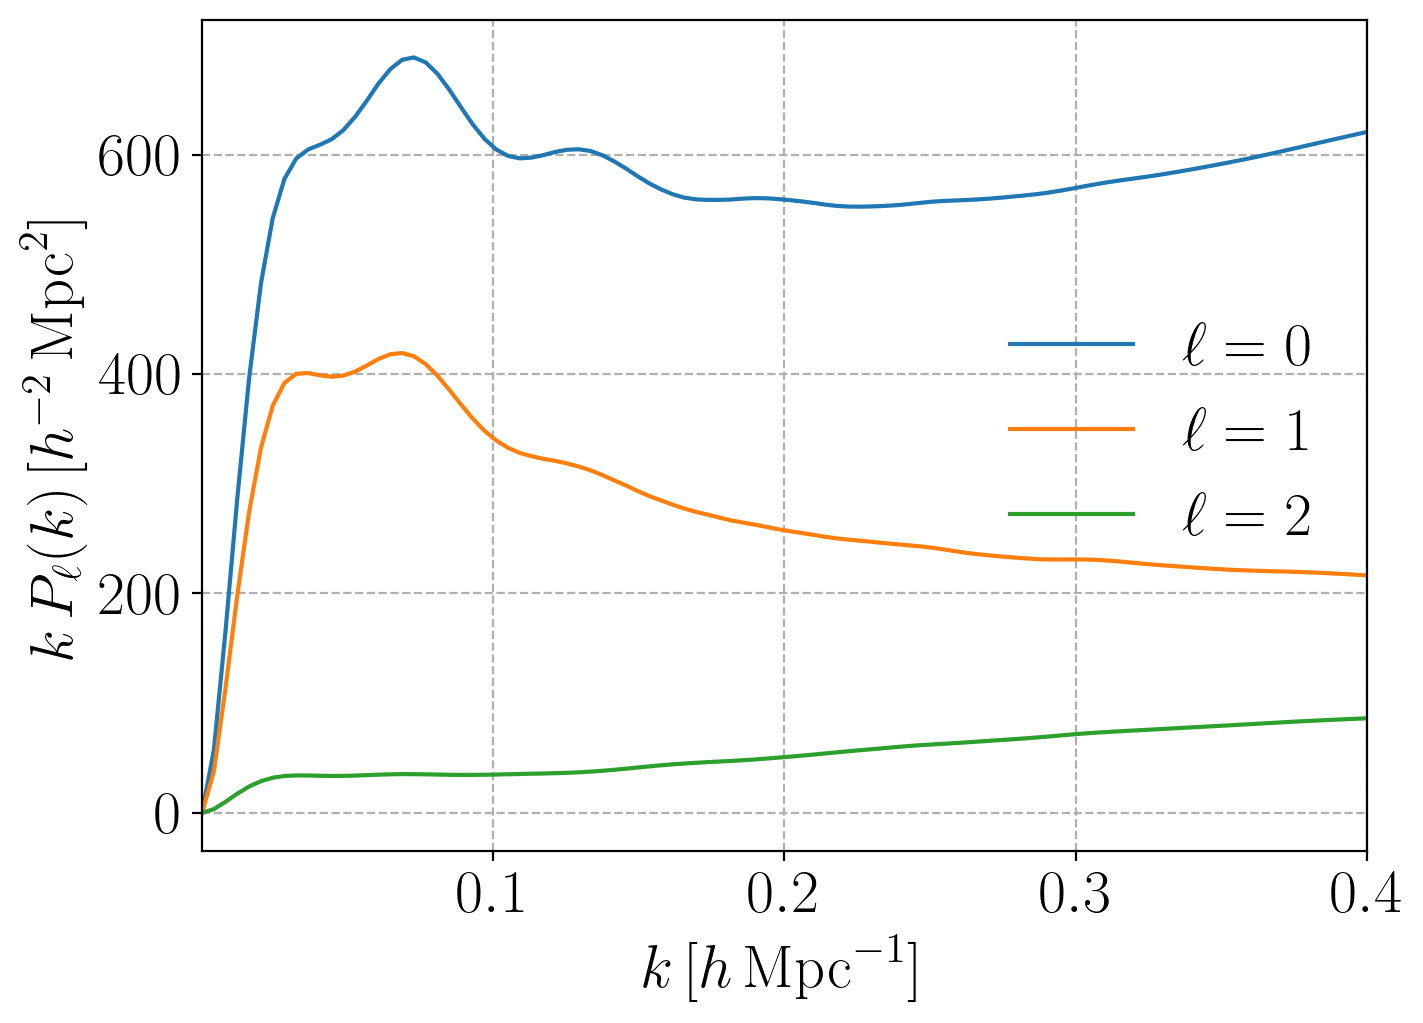

In [17]:
fig = plt.figure(figsize=(7,5),constrained_layout=True)
color = plt.rcParams['axes.prop_cycle'].by_key()['color']
ax = fig.add_subplot()
pk_ells_test_wrapper = pk_ells_test_wrapper.reshape(len(ells),k_test.shape[0])

for l,ell in enumerate(ells):
     ax.plot(k_test, k_test * pk_ells_test_wrapper[l,:], ls='-', label=r'$\ell = %s$' % (l))
axs = plt.gcf().get_axes()
for ax in axs:
    plt.sca(ax)
    plt.xlabel(r'$k \, [h \, \mathrm{Mpc}^{-1}]$')
    plt.ylabel(r'$k \, P_{\ell}(k) \, [h^{-2} \, \mathrm{Mpc}^2]$')
    plt.xlim(k_test.min(), k_test.max())
    plt.legend(frameon=False,ncols=1)
    plt.grid(linestyle='--')

### Compare Jacobians

Now we can compute and compare the Jacobian using `jax.jacfwd` versus using `numdifftools.Jacobian`.

In [18]:
k = jnp.linspace(5e-3, 0.25, 50)
ells = (0, 2, 4)

%time jac = jax.jacfwd(jitted_pk_fn, argnums=0)(packed_params, k=k)
print(jac.shape)

CPU times: user 9.96 s, sys: 342 ms, total: 10.3 s
Wall time: 4.73 s
(150, 22)


In [19]:
%time jac_nd = nd.Jacobian(lambda p: jitted_pk_fn(p, k=k), step=2e-4)(packed_params)
print(jac_nd.shape)

CPU times: user 32.4 s, sys: 1.9 s, total: 34.3 s
Wall time: 3.69 s
(150, 22)


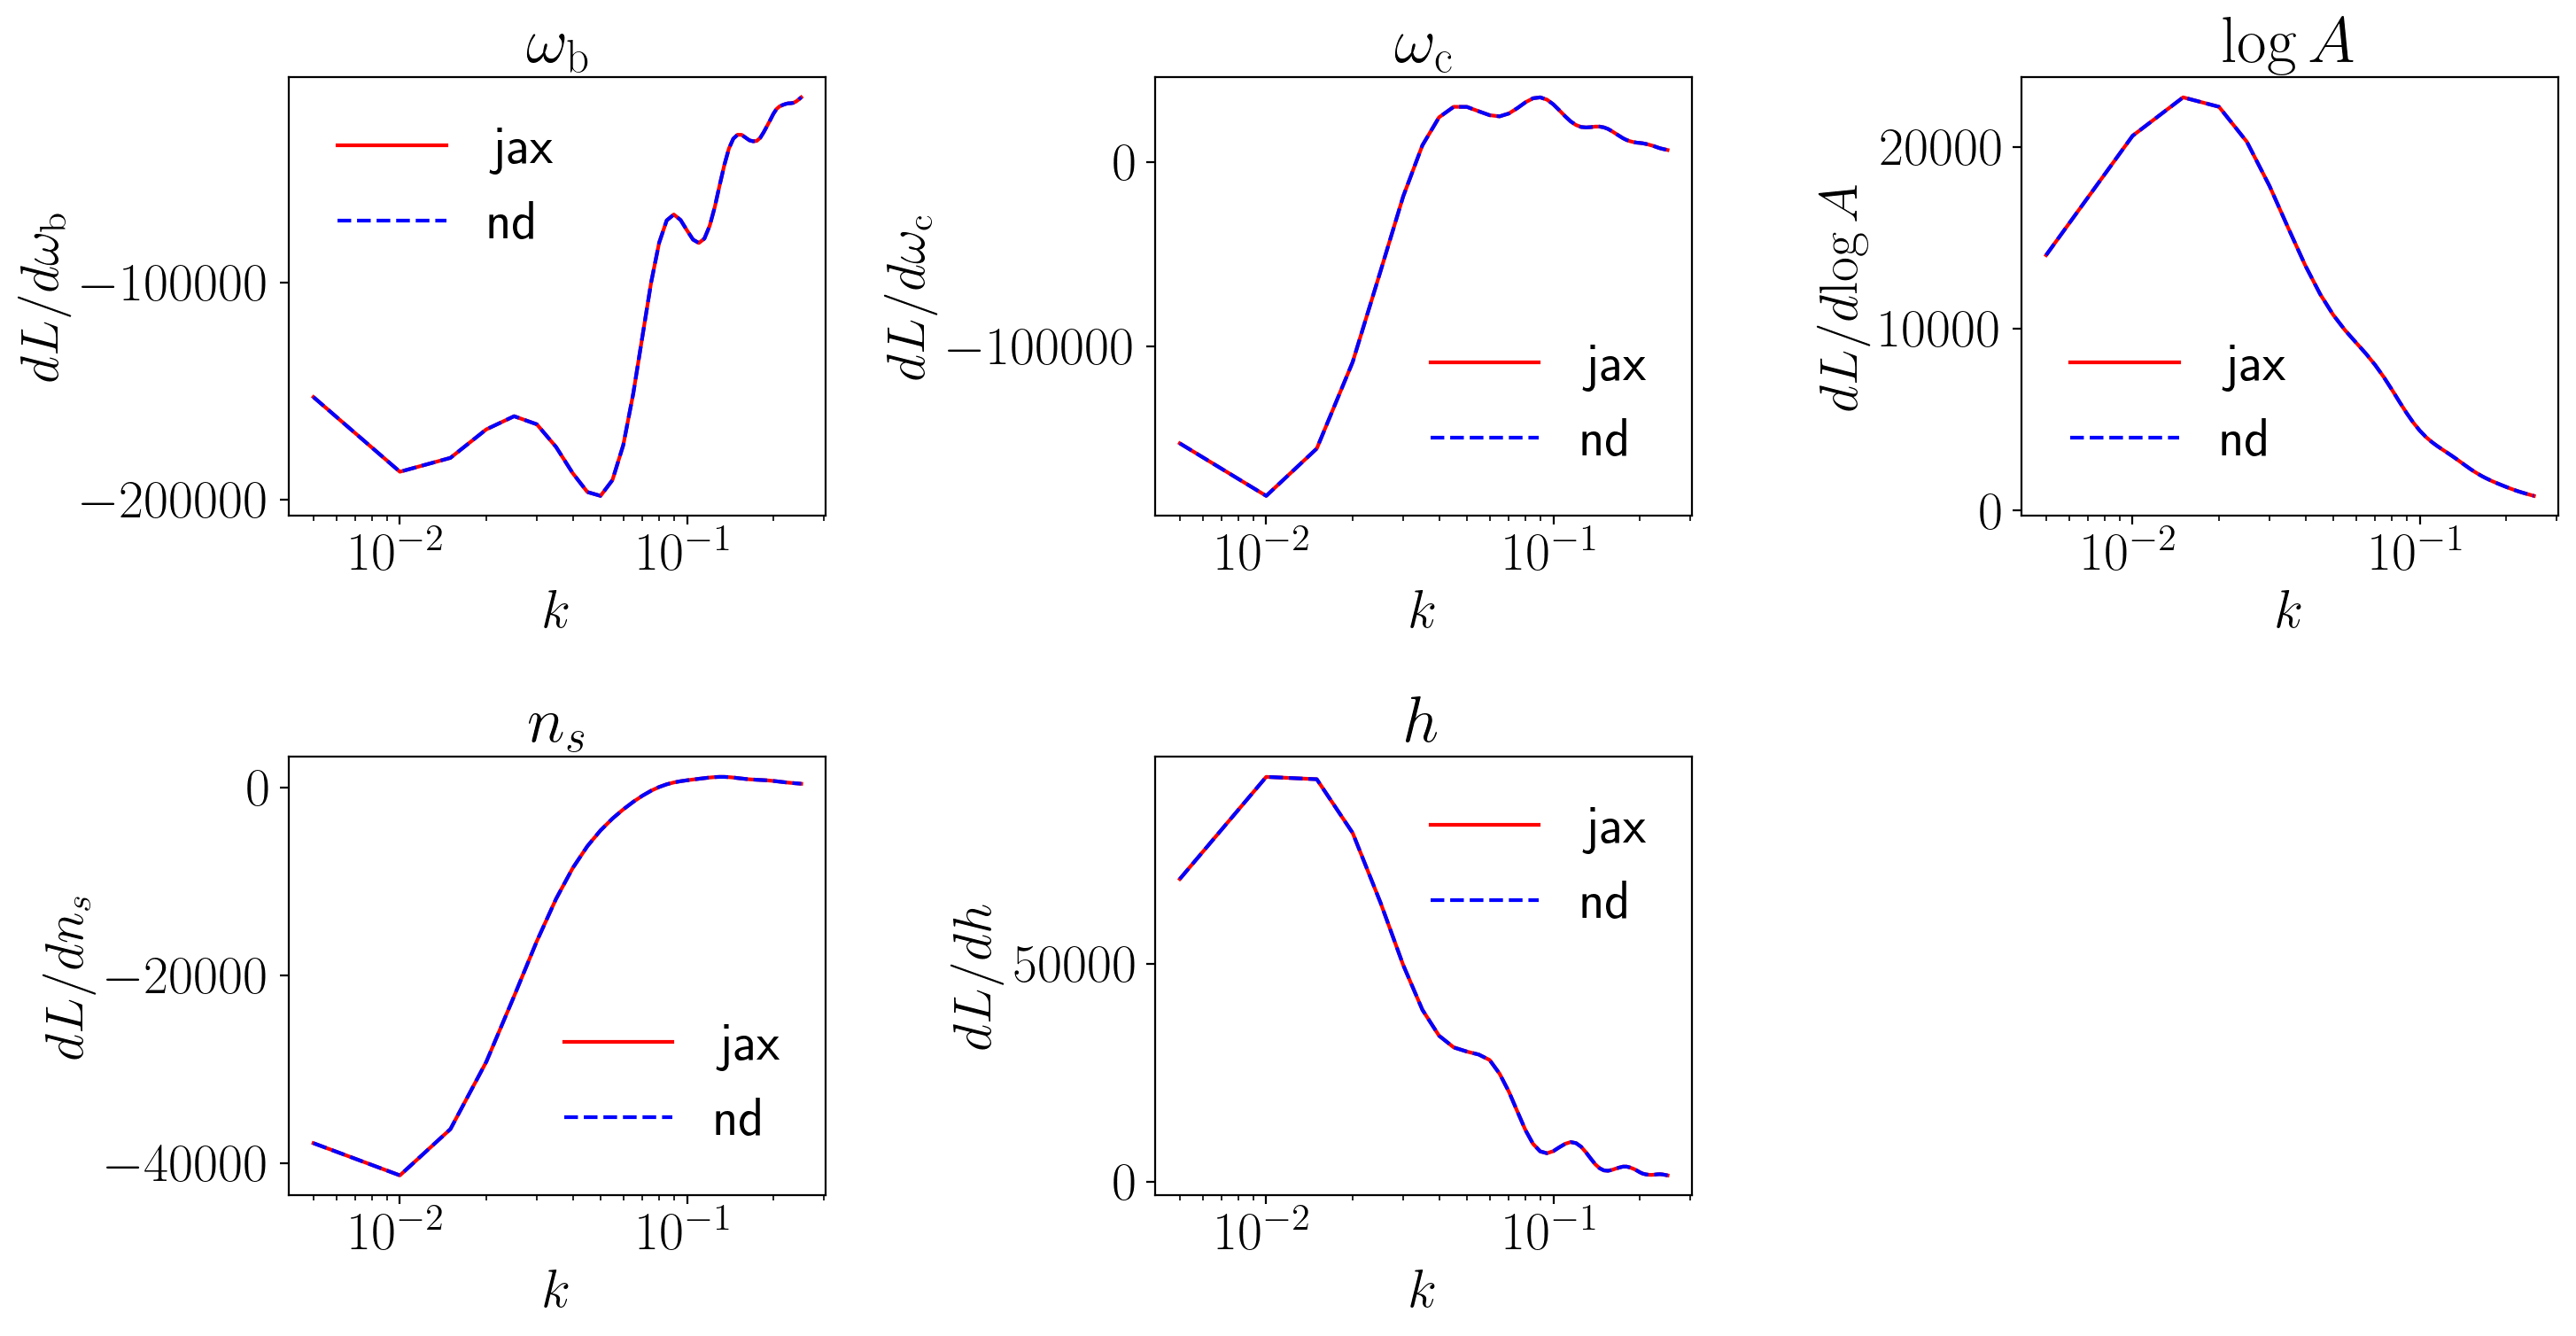

In [20]:
cosmo_params_idx=[0,1,2,3,4]
cosmo_params_labels = (r'$\omega_\mathrm{b}$', r'$\omega_\mathrm{c}$', r'$\log A$', r'$n_s$', r'$h$',)
cosmo_params_len=len(cosmo_params_labels)

fig, axs = plt.subplots(nrows=2, ncols=3, figsize=(15, 8))

for i in range(2):
    for j in range(3):
        idx = 3 * i + j
        ax = axs[i, j]
        if idx >= len(cosmo_params_labels):
            ax.axis('off')  # Hide unused subplot
            continue

        ax.semilogx(k, jac[:k.shape[0], idx], c='r', label='jax')
        ax.semilogx(k, jac_nd[:k.shape[0], idx], c='b', ls='--', label='nd')
        ax.set_title(cosmo_params_labels[idx])
        ax.set_xlabel(r'$k$')
        ax.set_ylabel(rf'$dL/d${cosmo_params_labels[idx]}')
        ax.legend(frameon=False)

plt.tight_layout()

## Compute Gaussian covariance

We proceed to compute the Gaussian covariance at fiducial cosmology.

In [21]:
# gaussian_covariance imported from jaxptpolypol.covariance

In [22]:
%time ps1loop_ells = jitted_pk_fn(packed_params, k=k).reshape(len(ells), k.shape[0])
gauss_cov = gaussian_covariance(V, k, k[1]-k[0], *ps1loop_ells)
print(gauss_cov.shape)

CPU times: user 103 ms, sys: 9.8 ms, total: 113 ms
Wall time: 10.7 ms
(150, 150)


## Compute Fisher matrix

In [23]:
# fisher_matrix imported from jaxptpolypol.inference

# Compare methods (all should agree)
fisher_cholesky_sol = fisher_matrix(gauss_cov, jac)
%timeit fisher_matrix(gauss_cov, jac)

fisher_direct = jac.T @ jsp.linalg.inv(gauss_cov) @ jac
%timeit jac.T @ jsp.linalg.inv(gauss_cov) @ jac

print(jnp.allclose(fisher_direct, fisher_cholesky_sol))

66.6 μs ± 4.73 μs per loop (mean ± std. dev. of 7 runs, 10,000 loops each)


209 μs ± 7.01 μs per loop (mean ± std. dev. of 7 runs, 10,000 loops each)
True


## Plot Fisher contours

### Helpers

Some helpers to plot cornerplots from Fisher matrix.

In [24]:
# plot_contours, plot_Gaussian, triangle_plot imported from jaxptpolypol.plotting

[0, 1, 2, 3, 4, 9, 10, 11, 12, 13, 16, 17, 18, 19, 20, 21]


Text(0.5, 0.98, '$P^{\\ell=[0,2,4]}_{\\mathrm{no\\,AP}}$ forecast')

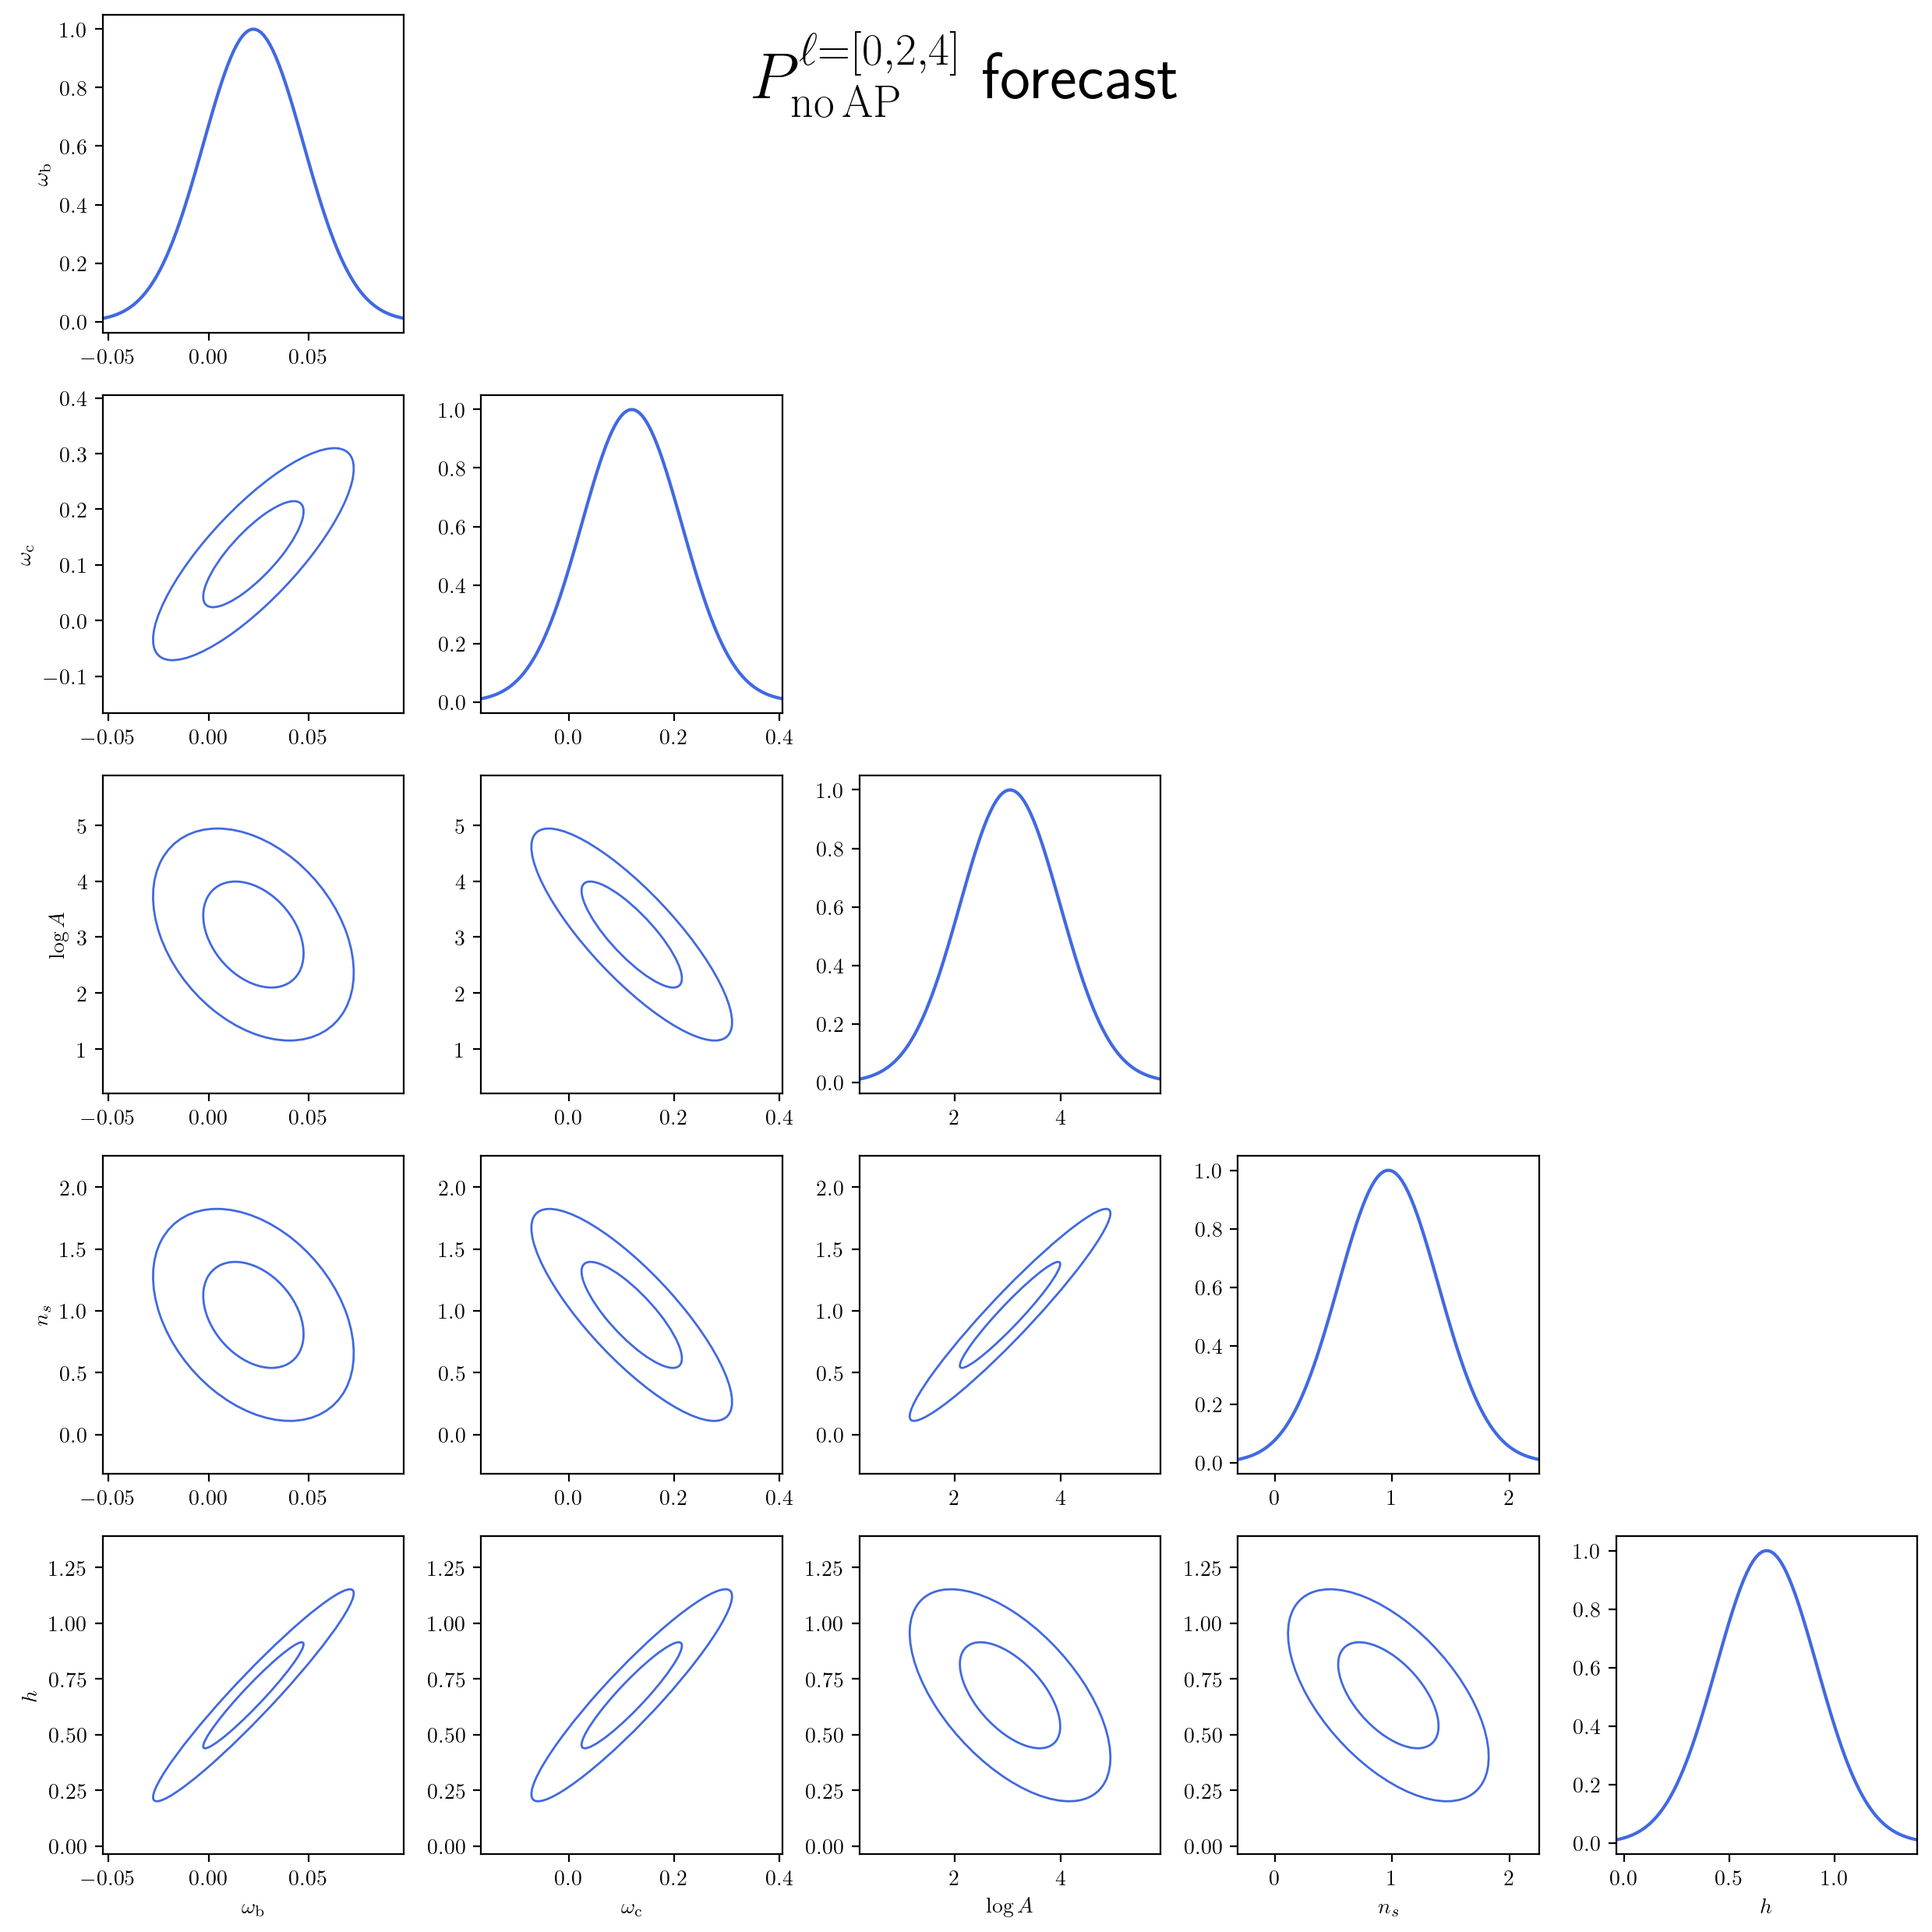

In [25]:
# Not very elegant, just for quick plotting, to be cleaned up later
cosmo_params_names = (r'$\omega_\mathrm{b}$', r'$\omega_\mathrm{c}$', r'$\log A$', r'$n_s$', r'$h$',)
cosmo_params_len = len(cosmo_params_names)
cosmo_params_idx = np.array([0, 1, 2, 3, 4])
all_params_idx = list(range(fisher_cholesky_sol.shape[0]))
fixed_survey_keys = {('shared', 'k_nl', None), ('shared', 'ndens', None)}
fixed_survey_offsets = [i for i, key in enumerate(pk_survey_keys) if key in fixed_survey_keys]
fixed_params_idx = [5, 6, 7, 8] + [len(cosmo.param_keys) + i for i in fixed_survey_offsets]
varied_params_idx = [i for i in all_params_idx if i not in fixed_params_idx]
print(varied_params_idx)

fig = plt.figure(figsize=(cosmo_params_len*2.5, cosmo_params_len*2.5))
plt.rcParams.update({
    "font.size": 10,
    "figure.constrained_layout.use": True})
plt.subplots_adjust(wspace=0.4, hspace=0.4)

for i in range(cosmo_params_len):
    for j in range(cosmo_params_len):
        if j < i:
            plt.subplot(cosmo_params_len, cosmo_params_len, i*cosmo_params_len+j+1)
            plot_contours(marginalize_fisher(fisher_cholesky_sol, varied_params_idx), packed_params[np.ix_(cosmo_params_idx)], np.array([j, i]), fill=False, color='royalblue', cls=[0.68, 0.95], level_kind="mass2d")
        if j == i:
            plt.subplot(cosmo_params_len, cosmo_params_len, i*cosmo_params_len+j+1)
            plot_Gaussian(marginalize_fisher(fisher_cholesky_sol, varied_params_idx), packed_params[np.ix_(cosmo_params_idx)], i, color='royalblue')
        if i == cosmo_params_len - 1:
            plt.xlabel(cosmo_params_names[j])
        if j == 0:
            plt.ylabel(cosmo_params_names[i])
            plt.tight_layout()
fig.suptitle(r'$P^{\ell=[0,2,4]}_{\mathrm{no\,AP}}$ forecast', fontsize=30)


In [26]:
# Projected constraints on standard parameters
def projected_sigmas_from_fisher(fisher, rcond=1e-12):
    fisher = np.asarray(fisher, dtype=float)
    fisher = 0.5 * (fisher + fisher.T)
    eigvals = np.linalg.eigvalsh(fisher)
    scale = max(float(np.max(np.abs(eigvals))) if eigvals.size else 0.0, 1.0)
    if np.count_nonzero(eigvals > rcond * scale) < fisher.shape[0]:
        return np.full(fisher.shape[0], np.inf)
    cov = np.linalg.inv(fisher)
    diag = np.diag(cov)
    return np.where(diag > 0.0, np.sqrt(diag), np.inf)

F_marg = marginalize_fisher(fisher_cholesky_sol, varied_params_idx)
native_cosmo_keys = tuple(cosmo.param_keys[int(i)] for i in cosmo_params_idx)
packed_varied = packed_params[np.array(varied_params_idx)]
cosmo_marg_idx = np.array([varied_params_idx.index(int(i)) for i in cosmo_params_idx])
selected_plot_specs = list(
    make_lcdm_corner_specs(
        native_cosmo_keys,
        pklin_emulator=pklin_emulator,
        mnu_fixed=float(cosmo_dict.get('mnu', 0.06)),
        fixed_cosmo_values=cosmo_dict,
    )
)

projection_cases = [
    {'label': 'PFS Pk no AP', 'fisher': F_marg, 'packed_varied': packed_varied, 'cosmo_marg_idx': cosmo_marg_idx},
]

selected_fisher_cases = []
for case in projection_cases:
    projection = project_case_to_specs(
        case['fisher'],
        case['packed_varied'],
        case['cosmo_marg_idx'],
        native_cosmo_keys,
        selected_plot_specs,
    )
    selected_fisher_cases.append({**case, 'projection': projection})

selected_param_names = selected_fisher_cases[0]['projection'].plot_names
selected_param_labels = selected_fisher_cases[0]['projection'].plot_labels

print('Marginalized 1-sigma constraints for selected projected parameters')
print('=' * 110)
header = f"{'Parameter':>18s}  {'Fiducial':>12s}"
for case in selected_fisher_cases:
    header += f"  {case['label']:>18s}"
print(header)
print('-' * len(header))

for i, name in enumerate(selected_param_labels):
    fid = float(selected_fisher_cases[0]['projection'].fid_plot[i])
    sigma_vals = [
        float(projected_sigmas_from_fisher(case['projection'].fisher_plot)[i])
        for case in selected_fisher_cases
    ]
    row = f"{name:>18s}  {fid:12.5g}"
    for sigma in sigma_vals:
        row += f"  {sigma:18.5g}" if np.isfinite(sigma) else f"  {'---':>18s}"
    print(row)


Marginalized 1-sigma constraints for selected projected parameters
         Parameter      Fiducial        PFS Pk no AP
----------------------------------------------------
        $\Omega_m$       0.31105            0.067018
             $H_0$         67.66              23.782
        $\sigma_8$       0.81038             0.23116
